# Day 2 — Exploratory Data Analysis
## Olist Brazilian E-Commerce Dataset

Goal: understand what's actually in these 9 tables, how they relate to each other, and surface the data characteristics that will drive our recommender design (basket sizes, repeat-purchase rate, category/price distribution).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

DATA_DIR = '../data/'


## 1. Load all tables

The Olist dataset is split across 9 CSVs. Let's load them all and check their shapes first, before looking at any content.


In [2]:
customers = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
orders = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
sellers = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
category_translation = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')
geolocation = pd.read_csv(DATA_DIR + 'olist_geolocation_dataset.csv')

tables = {
    'customers': customers, 'orders': orders, 'order_items': order_items,
    'order_payments': order_payments, 'order_reviews': order_reviews,
    'products': products, 'sellers': sellers,
    'category_translation': category_translation, 'geolocation': geolocation,
}
for name, df in tables.items():
    print(f'{name:22s} shape={df.shape}')


customers              shape=(99441, 5)
orders                 shape=(99441, 8)
order_items            shape=(112650, 7)
order_payments         shape=(103886, 5)
order_reviews          shape=(99224, 7)
products               shape=(32951, 9)
sellers                shape=(3095, 4)
category_translation   shape=(71, 2)
geolocation            shape=(1000163, 5)


## 2. How the tables relate (the schema)

This is a **relational** dataset — no single table has everything, so we join them via shared ID columns:

- `orders.customer_id` → `customers.customer_id` (but see the gotcha below!)
- `orders.order_id` → `order_items.order_id` (an order can have multiple items = a "basket")
- `order_items.product_id` → `products.product_id`
- `products.product_category_name` → `category_translation.product_category_name` (translates Portuguese → English)
- `order_items.seller_id` → `sellers.seller_id`
- `orders.order_id` → `order_reviews.order_id`
- `orders.order_id` → `order_payments.order_id`

**Gotcha**: `customers.customer_id` is actually a *per-order* identifier, not a *per-person* one — Olist generates a new `customer_id` for every order. The real person-level ID is `customers.customer_unique_id`. If you accidentally group by `customer_id`, every customer looks like a one-time buyer *by construction*, regardless of the real repeat-purchase rate. Let's check both.


In [3]:
orders_per_customer_id = customers.groupby('customer_id').size()
orders_per_person = customers.groupby('customer_unique_id').size()

print('Rows in customers table:', len(customers))
print('Unique customer_id:', customers['customer_id'].nunique())
print('Unique customer_unique_id (real people):', customers['customer_unique_id'].nunique())
print()
print('% of customer_id values used exactly once:', (orders_per_customer_id == 1).mean() * 100)
print('% of real people (customer_unique_id) who ordered exactly once:', (orders_per_person == 1).mean() * 100)


Rows in customers table: 99441
Unique customer_id: 99441
Unique customer_unique_id (real people): 96096

% of customer_id values used exactly once: 100.0
% of real people (customer_unique_id) who ordered exactly once: 96.88124375624375


## 3. Missing values

Quick scan across the tables we'll actually use for modeling.


In [4]:
for name in ['orders', 'order_items', 'products', 'order_reviews']:
    print(f'--- {name} ---')
    print(tables[name].isnull().sum()[tables[name].isnull().sum() > 0])
    print()


--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- order_items ---
Series([], dtype: int64)

--- products ---


product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- order_reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64



## 4. Basket size — how many items per order?

This matters a lot for our item-item collaborative filtering signal: co-purchase pairs can only come from orders with 2+ items. If almost every order has exactly 1 item, our collaborative signal will be sparse and we'll lean more heavily on the content-based fallback.


1     90.064460
2      7.617619
3      1.339874
4      0.511828
5      0.206758
6      0.200677
7      0.022297
8      0.008108
9      0.003041
10     0.008108
Name: proportion, dtype: float64

Mean items per order: 1.1417306873695092
% of orders with only 1 item: 90.06445989499929
% of orders with 2+ items (usable for co-purchase signal): 9.93554010500071


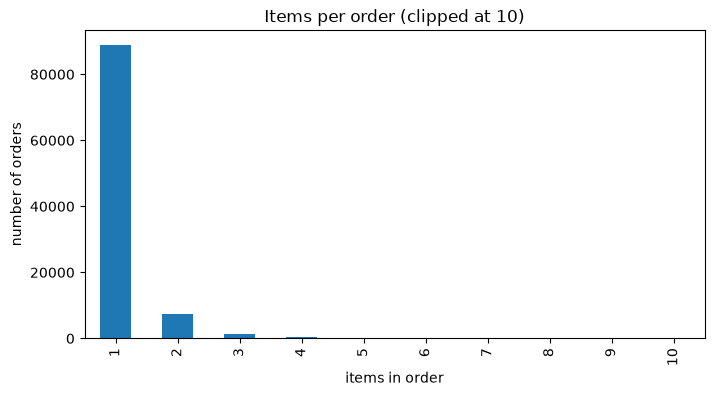

In [5]:
basket_sizes = order_items.groupby('order_id').size()
print(basket_sizes.value_counts(normalize=True).sort_index().head(10) * 100)
print()
print('Mean items per order:', basket_sizes.mean())
print('% of orders with only 1 item:', (basket_sizes == 1).mean() * 100)
print('% of orders with 2+ items (usable for co-purchase signal):', (basket_sizes >= 2).mean() * 100)

basket_sizes.clip(upper=10).value_counts().sort_index().plot(kind='bar', figsize=(8,4), title='Items per order (clipped at 10)')
plt.xlabel('items in order')
plt.ylabel('number of orders')
plt.show()


## 5. Product catalog & categories


In [6]:
products_named = products.merge(category_translation, on='product_category_name', how='left')
print('Total products:', len(products_named))
print('Unique categories:', products_named['product_category_name_english'].nunique())
print()
print(products_named['product_category_name_english'].value_counts().head(15))


Total products: 32951
Unique categories: 71

product_category_name_english
bed_bath_table              3029
sports_leisure              2867
furniture_decor             2657
health_beauty               2444
housewares                  2335
auto                        1900
computers_accessories       1639
toys                        1411
watches_gifts               1329
telephony                   1134
baby                         919
perfumery                    868
stationery                   849
fashion_bags_accessories     849
cool_stuff                   789
Name: count, dtype: int64


## 6. Price distribution


count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64


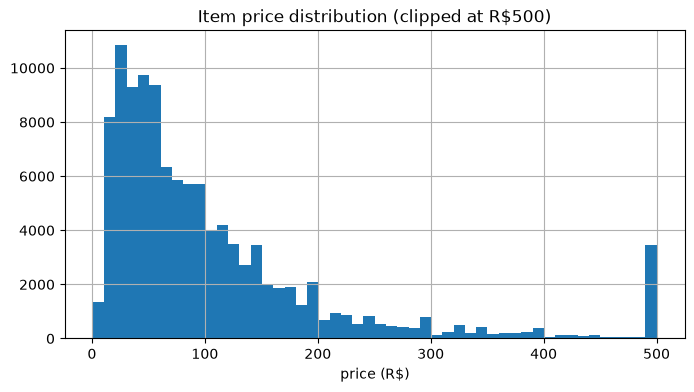

In [7]:
print(order_items['price'].describe())
order_items['price'].clip(upper=500).hist(bins=50, figsize=(8,4))
plt.title('Item price distribution (clipped at R$500)')
plt.xlabel('price (R$)')
plt.show()


## 7. Review scores

Not a direct signal for our recommender (we're not doing rating-based CF), but useful as a content-based quality feature and worth understanding.


In [8]:
print(order_reviews['review_score'].value_counts(normalize=True).sort_index() * 100)


review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64


## Summary — what this means for our recommender design

- The dataset genuinely has a very high one-time-buyer rate even measured correctly on `customer_unique_id` — traditional user-based collaborative filtering ("people like you also liked...") is not viable here.
- Basket sizes are small, so item-item co-purchase signal will be real but sparse — we need a content-based fallback for cold-start / rarely-co-purchased items.
- We have solid content features to fall back on: category, price, and (aggregated) review score.

**Next up (Day 3):** build the popularity baseline — the simplest possible recommender, which every smarter model needs to beat.
